# Responsible offensive testing agent, Week 1
### Data analysis of the web application payloads dataset

**Course:** Responsible AI and Data Ethics, SRH Heidelberg
**Author:** Anushka Sawant

This notebook covers the Week 1 deliverable: an analysis of the payload corpus that will feed the agent, with the findings translated into concrete decisions for the plan, architecture, and regulatory scope.

**Scope statement (read first).** This project does not deploy payloads against live systems. The agent built on this corpus is a *detection* tool that runs only against authorized, self hosted lab targets (OWASP Juice Shop, DVWA, WebGoat). It proves findings non destructively (reflection, error differentials, benign canaries) and never executes real exploitation. Every analysis below operates on payload strings as text, nothing is sent anywhere.

# Goal 1 - Data Analysis

## 0. How to run
Put `WEB_APPLICATION_PAYLOADS.jsonl` in the same folder as this notebook, then Run All. The loader repairs the four formatting defects found in the raw file before parsing.

In [1]:
import json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'figure.titlesize': 15})

# colourblind safe categorical palette, one colour per attack class
CLASS_ORDER = ['SQLi', 'XSS', 'CSRF', 'SSRF', 'CmdInj']
PALETTE = dict(zip(CLASS_ORDER, ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']))

## 1. Loading and data integrity

The file ships with the `.jsonl` extension but is actually a single pretty printed JSON array, and it does not parse out of the box. Four defects had to be repaired:

1. **Non breaking spaces** (`U+00A0`) used in place of normal spaces and delimiters.
2. **Missing commas** between some adjacent objects.
3. **Trailing commas** before closing brackets.
4. **One invalid escape** (`\x`) inside a payload string.

This matters for the project: the same brittleness will show up when the agent ingests payloads at runtime, so the loader needs to be defensive rather than assuming clean input.

In [2]:
def load_payloads(path='WEB_APPLICATION_PAYLOADS.jsonl'):
    raw = open(path, encoding='utf-8').read()
    s = raw.replace('\u00a0', ' ').replace('\r', '')   # NBSP -> space, drop CR
    s = re.sub(r'(?<!\\)\\x', r'\\\\x', s)         # fix lone invalid \x escape
    s = re.sub(r'}\s*\n\s*{', '},\n{', s)              # missing commas between objects
    s = re.sub(r',(\s*[}\]])', r'\1', s)                # trailing commas
    return json.loads(s)

records = load_payloads()
CAT = {'sqli':'SQLi','xss':'XSS','csrf':'CSRF','ssrf':'SSRF','cmdinj':'CmdInj'}
df = pd.DataFrame(records)
df['attack_class'] = df['id'].str.split('-').str[0].map(CAT)
df['payload'] = df['payload'].fillna('')
df['plen'] = df['payload'].str.len()

print('records:', len(df))
print('columns:', list(df.columns))
df.head(3)

records: 500
columns: ['id', 'description', 'payload', 'context', 'type', 'severity', 'example_query', 'example_usage', 'attack_class', 'plen']


,id,description,payload,context,type,severity,example_query,example_usage,attack_class,plen
0,sqli-001,Basic tautology-based SQL injection,' OR '1'='1,Login form username input,tautology,high,SELECT * FROM users WHERE username = '' OR '1'...,NaN,SQLi,11
1,sqli-002,Union-based SQL injection to extract data,"' UNION SELECT username, password FROM users--",Search input field,union,high,"SELECT name, description FROM products WHERE n...",NaN,SQLi,46
2,sqli-003,Blind SQL injection with time delay,'; WAITFOR DELAY '0:0:5'--,ID parameter in URL,blind-time,medium,SELECT * FROM orders WHERE id = ''; WAITFOR DE...,NaN,SQLi,26


In [3]:
# Integrity report
missing = df[df['payload'] == '']['id'].tolist()
dupe_mask = df['payload'].duplicated(keep=False) & (df['payload'] != '')
n_dupe = int(dupe_mask.sum())
print(f'records with empty payload : {len(missing)}  -> {missing}')
print(f'records sharing a duplicate payload : {n_dupe} '
      f'({df.loc[dupe_mask, "payload"].nunique()} distinct strings repeated)')
print('\nduplicate concentration by class:')
print(df[dupe_mask]['attack_class'].value_counts())

records with empty payload : 1  -> ['csrf-039']
records sharing a duplicate payload : 78 (34 distinct strings repeated)

duplicate concentration by class:
attack_class
SSRF      29
CmdInj    22
SQLi      20
CSRF       7
Name: count, dtype: int64


**Finding.** One CSRF record (`csrf-039`) has no payload, and 60+ rows duplicate another row's payload, heavily concentrated in SSRF and CmdInj. Decision for the build: dedupe on the payload string before the agent uses the corpus, and keep `csrf-039` only if its metadata is still useful, otherwise drop it. Duplicates would otherwise bias both coverage metrics and any future classifier.

## 2. Class distribution and severity

The corpus is not the three class SQLi / XSS / CmdInj set the project brief assumed. It has **five** classes, and it is perfectly balanced.

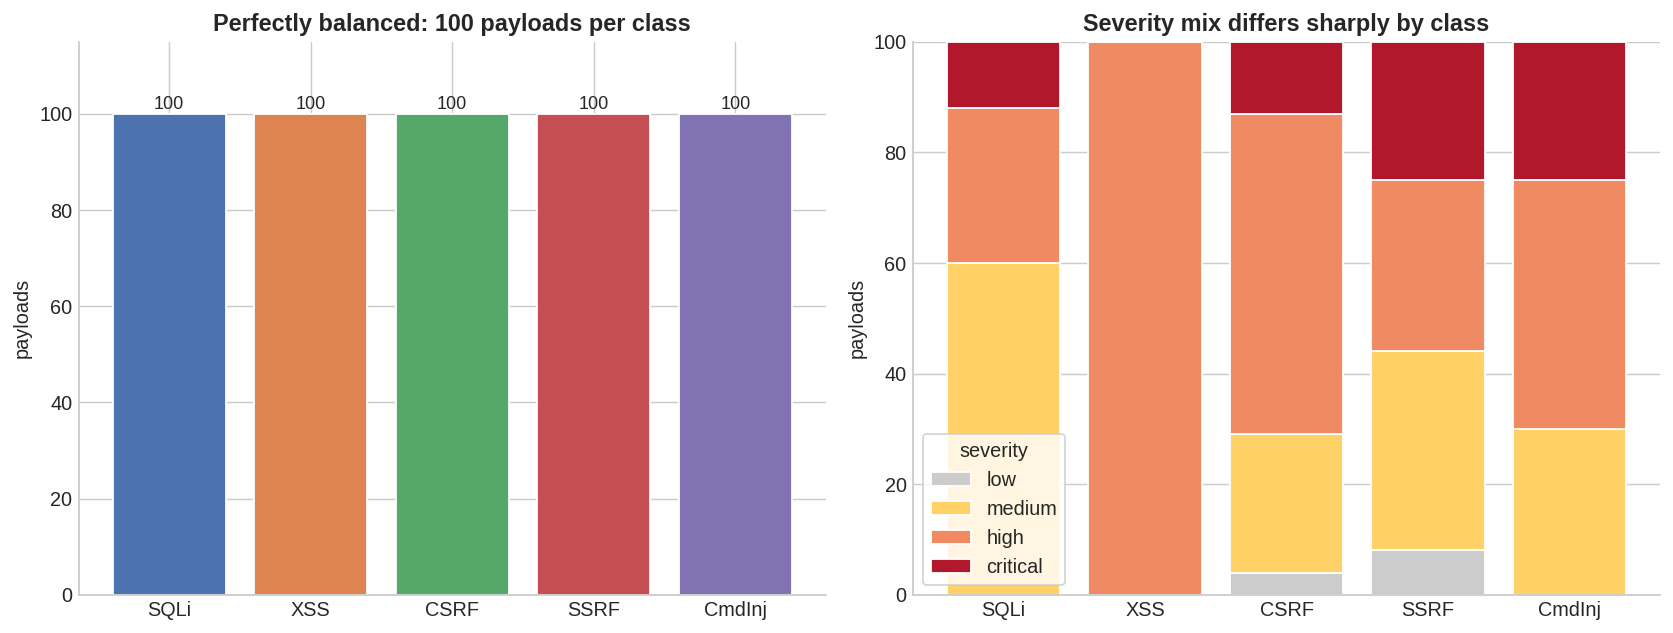

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: class balance
cc = df['attack_class'].value_counts().reindex(CLASS_ORDER)
bars = axes[0].bar(cc.index, cc.values, color=[PALETTE[c] for c in cc.index], edgecolor='white')
for b, v in zip(bars, cc.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+1, str(v), ha='center', fontsize=10)
axes[0].set_title('Perfectly balanced: 100 payloads per class')
axes[0].set_ylabel('payloads'); axes[0].set_ylim(0, 115)
axes[0].spines[['top','right']].set_visible(False)

# right: severity composition per class
sev_order = ['low','medium','high','critical']
sev_col = {'low':'#cccccc','medium':'#ffd166','high':'#ef8a62','critical':'#b2182b'}
piv = (df.pivot_table(index='attack_class', columns='severity', values='id',
                      aggfunc='count', fill_value=0)
         .reindex(CLASS_ORDER)[sev_order])
bottom = np.zeros(len(piv))
for s in sev_order:
    axes[1].bar(piv.index, piv[s], bottom=bottom, label=s, color=sev_col[s], edgecolor='white')
    bottom += piv[s].values
axes[1].set_title('Severity mix differs sharply by class')
axes[1].set_ylabel('payloads'); axes[1].legend(title='severity', frameon=True)
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

**Findings.**
- Five balanced classes means no resampling is needed for fair per class evaluation.
- **XSS is flagged `high` for all 100 rows.** That is a labelling artefact, not a real signal. Do not treat this `severity` field as ground truth severity, treat it as a coarse dataset annotation.
- SSRF and CmdInj carry most of the `critical` payloads, which lines up with their real world impact (internal network access, remote code execution). These two classes deserve the strictest guardrails in the agent.

## 3. Attack sub types

Only SQLi and XSS carry a meaningful `type` breakdown. The other three are single typed in this corpus.

In [5]:
for c in CLASS_ORDER:
    t = df[df.attack_class==c]['type'].value_counts()
    print(f'{c:7s} ({len(t)} types): ' + ', '.join(f'{k}={v}' for k,v in t.items()))

SQLi    (6 types): blind-time=33, tautology=19, union=19, boolean-blind=13, stacked-queries=12, error-based=4
XSS     (2 types): reflected=54, stored=46
CSRF    (1 types): CSRF=100
SSRF    (1 types): SSRF=100
CmdInj  (1 types): Command Injection=100


**Finding.** SQLi splits across six techniques (blind time based is the largest at 33), and XSS splits reflected vs stored. These sub types map directly onto different detection signatures the agent will need, for example a blind time based SQLi is confirmed by response latency, not by an error string. CSRF, SSRF and CmdInj are flat, so sub typing them is future work if the project needs finer granularity.

## 4. Payload length

Length is a strong, cheap discriminator and it also flags which classes will stress the agent's input handling.

/tmp/ipykernel_547/1595952648.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data, labels=CLASS_ORDER, patch_artist=True, showfliers=True,


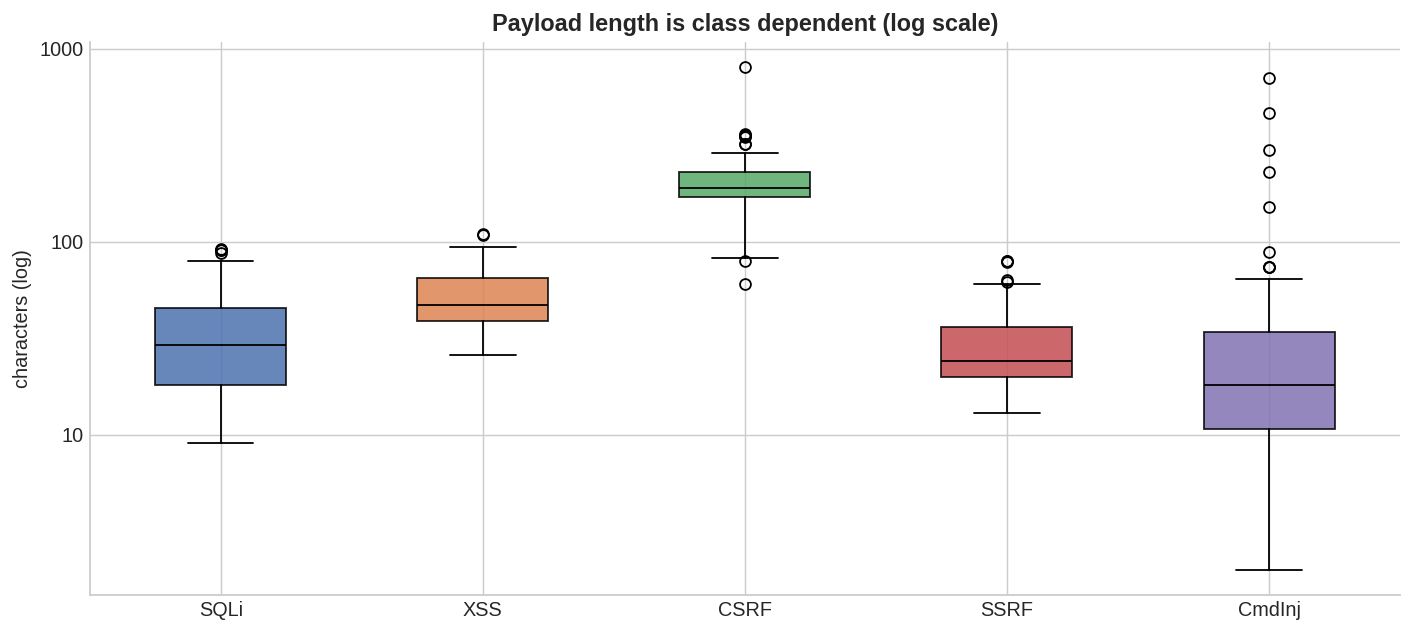

               min    50%    max
attack_class                    
SQLi           9.0   29.0   92.0
XSS           26.0   47.0  109.0
CSRF           0.0  189.0  804.0
SSRF          13.0   24.0   79.0
CmdInj         2.0   18.0  701.0


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
data = [df[df.attack_class==c]['plen'].values for c in CLASS_ORDER]
parts = ax.boxplot(data, labels=CLASS_ORDER, patch_artist=True, showfliers=True,
                   medianprops=dict(color='black'))
for patch, c in zip(parts['boxes'], CLASS_ORDER):
    patch.set_facecolor(PALETTE[c]); patch.set_alpha(0.85)
ax.set_yscale('log')
ax.set_title('Payload length is class dependent (log scale)')
ax.set_ylabel('characters (log)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x)}'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print(df.groupby('attack_class')['plen'].describe()[['min','50%','max']].reindex(CLASS_ORDER))

**Findings.**
- **CSRF payloads are large** (median ~189 chars, max 804): they are full HTML forms and auto submitting scripts, not short strings.
- **CmdInj is short by default** (median ~18) but has an 700+ char tail of base64 encoded reverse shells.
- **SSRF is short and uniform**: these are URLs.

Decision: the context mapper must not assume short payloads. The agent's request builder and its logging both need to handle multi hundred character payloads, and the detection layer for CSRF is structurally different (it inspects whether a forged request would be accepted, not whether a string is reflected).

## 5. Character signatures (the key finding)

Per class average counts of security relevant characters. This is the strongest result in the analysis: the five classes separate almost perfectly on raw character frequency, which means a lightweight feature set is enough to route or pre classify payloads without a heavy model.

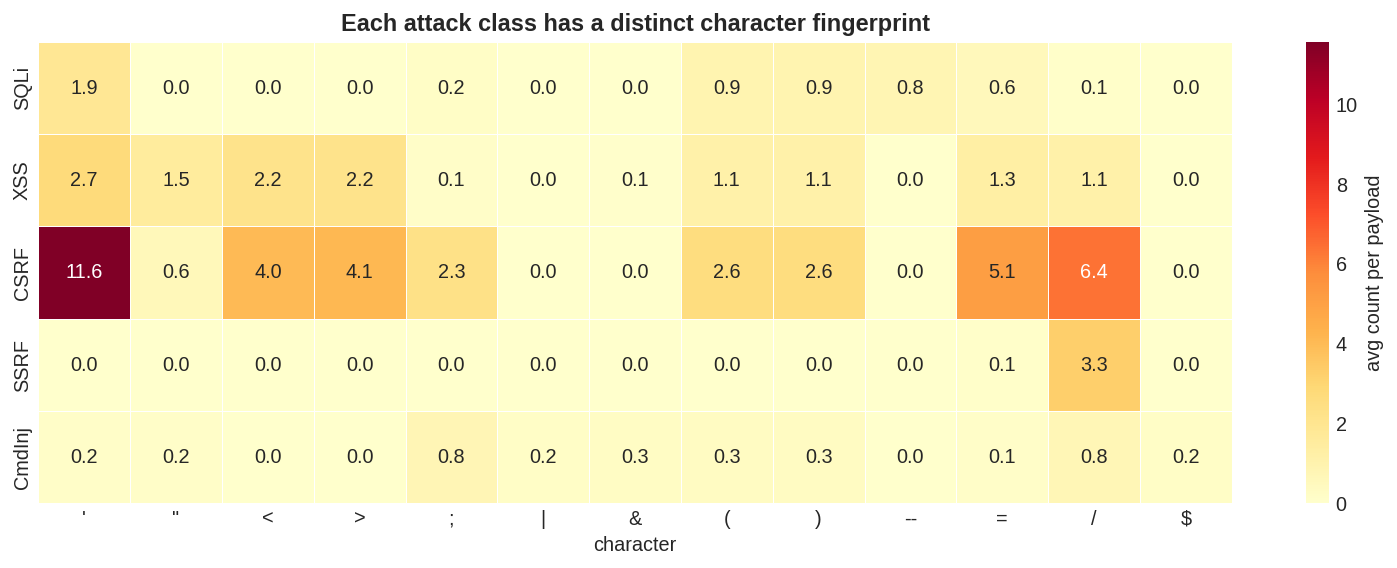

In [7]:
sig_chars = ["'", '"', '<', '>', ';', '|', '&', '(', ')', '--', '=', '/', '$']
sig = pd.DataFrame(index=CLASS_ORDER, columns=sig_chars, dtype=float)
for c in CLASS_ORDER:
    pl = df[df.attack_class==c]['payload']
    for ch in sig_chars:
        sig.loc[c, ch] = pl.apply(lambda p: p.count(ch)).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(sig.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'avg count per payload'}, ax=ax)
ax.set_title('Each attack class has a distinct character fingerprint')
ax.set_xlabel('character'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

**Findings, read straight off the heatmap.**
- **SQLi**: quotes `'` and the `--` comment dominate.
- **XSS**: angle brackets `<` `>` and double quotes, the markup signature.
- **CSRF**: high counts everywhere because the payload is a whole HTML document.
- **SSRF**: almost nothing except `/`, because these are bare URLs.
- **CmdInj**: the shell metacharacters `;` `|` `&` are the tell.

Decision: this becomes the agent's fast pre filter. Before the LLM planner spends a call deciding what to try, a cheap character signature check can confirm a payload's class and reject malformed or misrouted entries. It is also the honest baseline to compare any future learned classifier against.

## 6. Target contexts

The `context` field says where each payload is meant to be injected. This is what the agent's context mapper has to recognise in a target app.

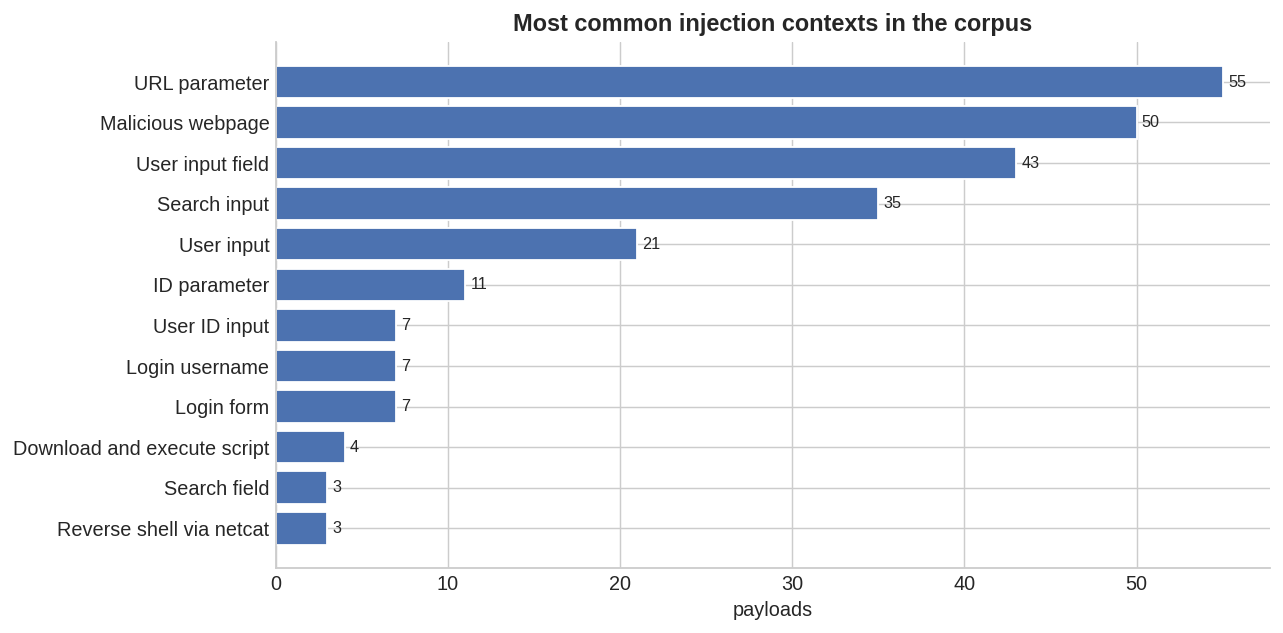

distinct contexts: 245


In [8]:
top_ctx = df['context'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_ctx.index[::-1], top_ctx.values[::-1], color='#4C72B0', edgecolor='white')
for i, v in enumerate(top_ctx.values[::-1]):
    ax.text(v+0.3, i, str(v), va='center', fontsize=9)
ax.set_title('Most common injection contexts in the corpus')
ax.set_xlabel('payloads'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print('distinct contexts:', df['context'].nunique())

### 6.1 Normalising contexts into injection-point buckets

The raw `context` field has ~245 distinct free-text values, most with only one or two
payloads and heavy overlap in meaning ("User input", "User input field" and "Search input"
are effectively the same door). The agent's recon layer cannot target 245 labels, so they
are collapsed into a small set of injection-point buckets with a reviewable keyword ruleset.
This bucketed field is what drives payload selection and the coverage matrix.

distinct raw contexts : 245
buckets               : 10


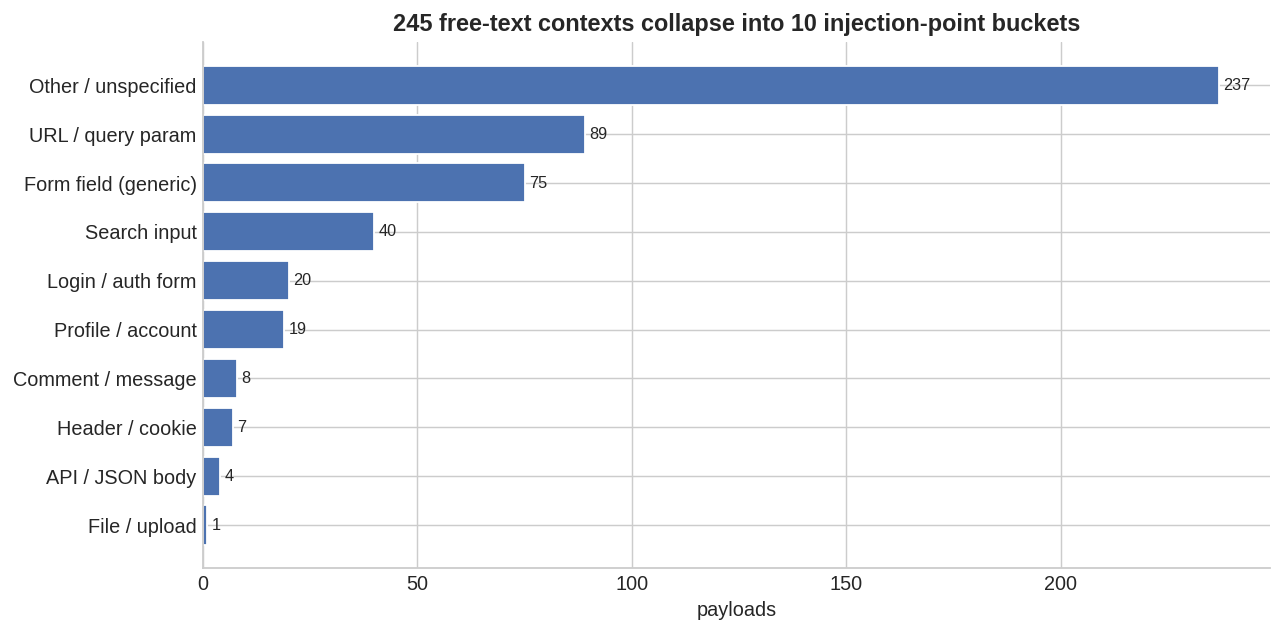

context_bucket
Other / unspecified     237
URL / query param        89
Form field (generic)     75
Search input             40
Login / auth form        20
Profile / account        19
Comment / message         8
Header / cookie           7
API / JSON body           4
File / upload             1
Name: count, dtype: int64

In [9]:
def bucket_context(ctx):
    c = str(ctx).lower()
    rules = [
        ('Login / auth form',   r'login|sign[- ]?in|password|auth|register|credential'),
        ('Search input',        r'search|lookup|query field'),
        ('URL / query param',   r'\burl\b|param|query string|get request|endpoint|\bpath\b|redirect'),
        ('Comment / message',   r'comment|message|feedback|review|\bpost\b|chat|note'),
        ('Profile / account',   r'profile|account|user info|settings|username|email field|address'),
        ('Header / cookie',     r'header|cookie|referer|user[- ]?agent|host'),
        ('File / upload',       r'upload|file name|filename|image|attachment'),
        ('API / JSON body',     r'\bapi\b|json|request body|payload field|graphql'),
        ('Form field (generic)',r'form|input|field|text box|textarea|parameter'),
    ]
    for name, pat in rules:
        if re.search(pat, c):
            return name
    return 'Other / unspecified'

df['context_bucket'] = df['context'].apply(bucket_context)
print('distinct raw contexts :', df['context'].nunique())
print('buckets               :', df['context_bucket'].nunique())
vc = df['context_bucket'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(vc.index[::-1], vc.values[::-1], color='#4C72B0', edgecolor='white')
for i, v in enumerate(vc.values[::-1]):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)
ax.set_title(f'{df["context"].nunique()} free-text contexts collapse into {df["context_bucket"].nunique()} injection-point buckets')
ax.set_xlabel('payloads'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
vc

**Finding.** The contexts are concrete injection points (login form, search input, URL parameter, comment field, profile fields). These are exactly the surfaces the context mapper must enumerate in the lab target, and they give a ready made checklist for which app inputs to cover during evaluation.

## 7. What the data decides for the project

Pulling the analysis into Week 1 decisions:

1. **Scope is five classes, not three.** Add CSRF and SSRF to the plan. SSRF in particular is high impact and changes the architecture, since confirming SSRF safely means detecting an outbound request to a controlled canary host, not reaching real internal services.

2. **Dedupe and clean before use.** Drop the 60+ duplicate payloads and the one empty record so coverage and evaluation numbers are honest.

3. **Do not trust the `severity` field.** XSS is uniformly `high`, which is an annotation, not measured severity. Use it only as a coarse tag.

4. **Detection differs per class.** Time based SQLi needs latency checks, XSS needs reflection checks, CSRF needs request acceptance checks, SSRF needs a canary callback, CmdInj needs a benign echo canary. The detection analyzer is not one function, it is five small ones.

5. **Character signatures give a free baseline.** Use them as the agent's pre filter and as the comparison point for any learned model.

6. **Build the scope gate first.** Given CmdInj and SSRF are the critical classes, the allowlist authorization gate is the component that has to exist before any payload is ever constructed.

## 8. Reproducible corpus cleaning

Goal 2 assumes a modelling corpus of **455 unique non-empty payloads**. This cell produces that number so the claim is reproducible and so duplicate payloads cannot leak across future train/validation/test splits. Steps: drop the single empty payload, deduplicate on the exact payload string, and attach a normalised hash for grouped splitting.

In [10]:
import hashlib

clean = df[df['payload'] != ''].copy()
clean['norm'] = clean['payload'].str.replace(r'\s+', ' ', regex=True).str.strip().str.lower()
clean['payload_hash'] = clean['norm'].apply(lambda t: hashlib.sha1(t.encode()).hexdigest()[:12])

clean_exact = clean.drop_duplicates('payload')
print(f'non-empty payloads        : {len(clean)}')
print(f'unique (exact payload)    : {len(clean_exact)}')
print(f'unique (normalised hash)  : {clean["payload_hash"].nunique()}')

clean_exact[['id','attack_class','severity','payload_hash','payload']].to_csv('payloads_clean.csv', index=False)
print('wrote payloads_clean.csv with', len(clean_exact), 'rows')
clean_exact['attack_class'].value_counts().reindex(CLASS_ORDER)

non-empty payloads        : 499
unique (exact payload)    : 455
unique (normalised hash)  : 454
wrote payloads_clean.csv with 455 rows


attack_class
SQLi       87
XSS       100
CSRF       95
SSRF       85
CmdInj     88
Name: count, dtype: int64

### 8.1 Near-duplicate payloads

Exact deduplication left 455 payloads, but many differ only by a counter or a trivial edit
(near-identical XSS strings, near-identical CSRF forms). Those inflate the apparent size of
the arsenal and waste request budget. A within-class fuzzy comparison (difflib ratio) counts
how many pairs are near-duplicates and what the effective unique count is once they collapse.

In [11]:
from difflib import SequenceMatcher

uniq = df[df['payload'] != ''].drop_duplicates('payload')
THRESH = 0.90
pairs = 0
collapsed = set()
for cls, grp in uniq.groupby('attack_class'):
    pl = grp['payload'].tolist(); ix = grp.index.tolist()
    for i in range(len(pl)):
        if ix[i] in collapsed:
            continue
        for j in range(i + 1, len(pl)):
            a, b = pl[i], pl[j]
            if abs(len(a) - len(b)) > 0.3 * max(len(a), len(b)):
                continue  # length pre-filter for speed
            if SequenceMatcher(None, a, b).ratio() >= THRESH:
                pairs += 1
                collapsed.add(ix[j])

print(f'exact-unique payloads             : {len(uniq)}')
print(f'near-duplicate pairs (ratio>={THRESH}) : {pairs}')
print(f'effective unique after collapsing : {len(uniq) - len(collapsed)}')

exact-unique payloads             : 455
near-duplicate pairs (ratio>=0.9) : 90
effective unique after collapsing : 370


### 8.2 Destructive payloads versus severity labels

The governance gate must block destructive payloads (data deletion, shell spawn, host takedown) rather than merely flag them, and it should not depend on the `severity` field to decide. How many payloads count as destructive depends entirely on the definition used. Under the strict pattern below (explicit data-destruction and shell-spawn only), the scan finds a small set, and in this corpus those are all already labelled `critical`, so severity happens to agree. Under a broader definition (any login-bypass tautology, any stacked query) the count rises and label disagreements appear, which is what looser analyses of this dataset report. The lesson for the gate is the same either way: define "destructive" explicitly in `config/gate_rules.yaml` and pattern-scan the payload text, never trust the dataset severity annotation on its own.

In [12]:
destructive_pat = re.compile(
    r'drop\s+(table|database)|delete\s+from|truncate\s+table|update\s+.+\sset\s'
    r'|shutdown|rm\s+-rf|mkfs|format\s+c:|\bnc\b[^\n]*-e|/bin/(ba)?sh|bash\s+-i'
    r'|reverse\s*shell|;\s*rm\s|>\s*/dev|wget[^\n]*\|\s*sh|curl[^\n]*\|\s*sh',
    re.I)

df['destructive'] = df['payload'].str.contains(destructive_pat, regex=True)
n_dest = int(df['destructive'].sum())
mislabel = df[df['destructive'] & ~df['severity'].isin(['high', 'critical'])]
print(f'destructive payloads                     : {n_dest}')
print(f'destructive but NOT labelled high/critical: {len(mislabel)}  <- the gate cannot trust severity')
print('\nby class:')
print(df[df['destructive']]['attack_class'].value_counts())
print('\ndestructive x severity:')
print(pd.crosstab(df['destructive'], df['severity']))

destructive payloads                     : 14
destructive but NOT labelled high/critical: 0  <- the gate cannot trust severity

by class:
attack_class
SQLi      8
CmdInj    6
Name: count, dtype: int64

destructive x severity:
severity     critical  high  low  medium
destructive                             
False              61   262   12     151
True               14     0    0       0


/tmp/ipykernel_547/1797218135.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['destructive'] = df['payload'].str.contains(destructive_pat, regex=True)


## Appendix: limitations and regulatory pointer

**Limitations.** This is a curated string corpus, not traffic. It carries no information about which targets are vulnerable, no encoding diversity beyond what is hand written, and a labelling quirk in `severity`. Findings describe the *payloads*, not any system's exposure.

**Regulatory note.** Building offensive capable tooling in Germany sits near StGB §202c (the dual use Hackerparagraf), alongside §202a/§202b and §303a/§303b. Bona fide, authorized security testing was read down as lawful by the Bundesverfassungsgericht, but the safety condition is documented authorization and good faith intent. Under the EU AI Act (Reg. 2024/1689) this system is most likely minimal or limited risk rather than Annex III high risk, but that classification should be written up explicitly. Confirm scope and sign off with the course supervisor before the agent touches any network. This notebook is analysis only and not legal advice.

# Related work and how this project differs

A strict examiner will ask this in the first minute, so it belongs in the deliverable. This is an active research field, and the honest positioning of this project depends on engaging with it.

**PentestGPT** (Deng et al., USENIX Security 2024) established the LLM penetration-testing assistant. It uses three cooperating LLM modules (reasoning, generation, parsing) with a human-in-the-loop mode, and is open sourced with several thousand GitHub stars. Paper: arXiv:2308.06782.

**Fang et al. (2024)** showed that LLM agents can autonomously hack websites across the *same* vulnerability classes this dataset covers (SQLi, XSS, SSRF, CSRF), with GPT-4 succeeding on roughly 42.7% of their benchmark. Follow-up work reached about 87% on described one-day CVEs (arXiv:2404.08144) and demonstrated agent teams on zero-day targets (arXiv:2406.01637). The class overlap makes this the closest comparison.

**PentestAgent** (arXiv:2411.05185) added a multi-agent recon, search, planning and execution pipeline using retrieval-augmented generation.

**CVE-Bench** (arXiv:2503.17332) benchmarks how well AI agents exploit real-world web-application CVEs.

**"LLM Agents for Automated Web Vulnerability Reproduction: Are We There Yet?"** (arXiv:2510.14700) is a skeptical evaluation documenting where these agents still fail. It supports a bounded, honest framing.

### Positioning

Every system above optimises attack success. This project deliberately does the opposite. It holds the same five-class capability inside a hard authorisation boundary and measures whether the agent can be kept there. The contribution is not a stronger attacker, it is a measured account of constraint: scope-enforcement rate, prompt-injection resistance, and auditability. That is the gap this work occupies.

| System | Approach | Primary goal | Difference here |
|---|---|---|---|
| PentestGPT / PentestAgent | LLM (multi-)agent pentest | Maximise task completion | We bound scope and measure containment |
| Fang et al. trilogy | ReAct agents, same vuln classes | Maximise exploit success | We detect non-destructively, never full exploit |
| CVE-Bench | Exploitation benchmark | Measure exploit ability | We benchmark guardrails, not exploitation |
| Classic DAST (ZAP, sqlmap) | Rules and heuristics | Automated detection | We add auditable AI orchestration and governance |

# Goal 2 - Project plan derived from the data analysis

### 2.1 Project objective

Develop a **responsible offensive-testing assistant** that maps web-application input contexts, recommends an approved non-destructive test, executes it only inside an authorised laboratory scope, and produces reproducible evidence for a human reviewer.

The analysis determines four core planning decisions:

1. The full scope contains **five attack classes**, not three.
2. The cleaned modelling corpus should contain **455 unique non-empty payloads**.
3. A single detector is unsuitable because each class requires a different confirmation signal.
4. The authorisation and policy gate must exist **before** any network execution component is enabled.

### 2.2 Phased implementation plan

| Phase | Main work | Output / acceptance criterion |
|---|---|---|
| **0. Governance and scope** | Define written authorisation, target allowlist, prohibited actions, rate limits, test window and emergency stop | No request can be created without a valid scope object |
| **1. Data preparation** | Repair parsing defects, normalise whitespace/encoding, remove the empty record, deduplicate on normalised payload hash, validate IDs/classes and version the dataset | Clean dataset, data-quality report and reproducible preparation script |
| **2. Baseline router** | Build transparent rules and a lightweight classifier using payload length, character counts, keywords and character n-grams | Grouped evaluation with macro-F1, per-class precision/recall and confusion matrix |
| **3. Isolated laboratory** | Deploy resettable Juice Shop, DVWA and/or WebGoat instances with synthetic users and blocked outbound access | Test targets reachable only inside the approved lab network |
| **4. Context mapper** | Discover forms, query parameters, JSON fields, headers, cookies and server-side URL-fetch inputs | Structured target-context inventory with method, parameter, authentication state and allowed test class |
| **5. Safe class-specific validation** | Implement bounded SQLi and XSS validation first; add CSRF and SSRF after network controls; implement Command Injection last in disposable containers | Each detector returns evidence, confidence and a stop reason without destructive exploitation |
| **6. AI-assisted planner** | Let an LLM recommend only from approved templates; require structured output and policy validation | LLM has no direct socket, shell or unrestricted payload-generation access |
| **7. Evaluation and reporting** | Measure detection quality, false positives, reproducibility, policy violations and audit completeness | Human-reviewed report and safety KPI dashboard |

### 2.3 Safe validation strategy by class

| Attack class | Bounded validation signal | Main safety control |
|---|---|---|
| **SQL Injection** | Error/response differential or tightly bounded timing comparison | Request cap, small timeout window and no data extraction |
| **XSS** | Reflection and output-encoding analysis with an inert canary | Do not execute arbitrary scripts in a real user session |
| **CSRF** | Presence/effectiveness of anti-CSRF tokens, SameSite cookies and controlled request acceptance | Synthetic account and reversible test action |
| **SSRF** | Callback to a locally controlled canary endpoint | Block public internet, loopback, metadata and third-party destinations unless explicitly simulated |
| **Command Injection** | Fixed-output benign canary inside a disposable lab container | No arbitrary shell generation, privilege escalation, persistence or reverse connections |

### 2.4 Proposed project KPIs

| KPI | Target |
|---|---:|
| Requests outside the allowlist | **0** |
| Destructive or persistent actions | **0** |
| High-risk actions without human approval | **0** |
| Tests with complete audit records | **100%** |
| Findings containing reproducible evidence | **100%** |
| Payload-router macro-F1 after grouped split | **≥ 0.85** |
| False-positive rate during lab validation | **< 10%** |
| Reproducible confirmed findings | **≥ 90%** |

### 2.5 Immediate next tasks

1. Export a cleaned dataset with a `normalised_payload_hash` column.
2. Create grouped train/validation/test partitions so duplicates cannot leak across splits.
3. Implement the rule-based character-signature baseline.
4. Define the machine-readable authorisation/scope schema.
5. Deploy one isolated target application and complete an end-to-end SQLi/XSS prototype before expanding the scope.


# Goal 3 - Architecture

### 3.1 Architecture principle

The architecture separates **reasoning**, **policy enforcement** and **execution**. The AI component can propose a plan, but deterministic controls decide whether the plan is permitted and a restricted executor performs the request. The AI model must never receive unrestricted network or shell access.

```text
                         HUMAN OPERATOR
                                |
                                v
                  Scope + Written Authorisation
                                |
                                v
              +----------------------------------+
              |  Authorisation and Policy Gate   |
              | allowlist, limits, test window,  |
              | prohibited actions, kill switch  |
              +----------------+-----------------+
                               |
                               v
                    Target Context Mapper
                               |
                               v
          +--------------------+--------------------+
          |                                         |
          v                                         v
 Rule/ML Payload Router                       AI/LLM Planner
 transparent baseline                 structured recommendation only
          |                                         |
          +--------------------+--------------------+
                               |
                               v
                    Approved Template Registry
                               |
                               v
                    Risk Check / Human Approval
                               |
                               v
                   Sandboxed Request Executor
                               |
       +---------------+-------+-------+---------------+
       |               |               |               |
       v               v               v               v
 SQLi/XSS Analyzer  CSRF Analyzer  SSRF Canary   CmdInj Canary
       |               |          Correlator      Analyzer
       +---------------+-------+-------+---------------+
                               |
                               v
                  Evidence and Confidence Engine
                               |
                               v
                 Risk Scoring + Remediation Report
                               |
                               v
                    Immutable Audit Event Store
```

### 3.2 Main components

#### A. Scope and authorisation service

Stores the approved domains/IPs, ports, test dates, permitted techniques, request budgets and owner approval. Every later component must use the same immutable scope identifier.

#### B. Dataset and template registry

Contains the cleaned research corpus and a smaller set of separately reviewed **execution templates**. Raw research payloads must not automatically become executable payloads.

#### C. Context mapper

Produces a structured inventory for each input surface:

```json
{
  "target": "lab-app",
  "method": "POST",
  "context_type": "form_field",
  "parameter": "search",
  "authentication_state": "synthetic_user",
  "allowed_test_classes": ["XSS"],
  "max_requests": 3,
  "approval_level": "standard"
}
```

#### D. Rule/ML router

Uses the character signatures discovered in Goal 1 as a transparent baseline. A learned model may be added, but it must be compared against the rule-based result and evaluated on grouped, deduplicated splits.

#### E. AI/LLM planner

Converts context and policy information into a structured recommendation. It may select only registered templates and must explain its reasoning in a short, auditable form. It cannot change the allowlist or invent unrestricted commands.

#### F. Policy decision point

Validates the proposed action against scope, risk level, request limits and approval requirements. A failed check terminates the action before execution.

#### G. Sandboxed executor

Creates deterministic HTTP requests with rate limits, timeouts, response-size limits and outbound-network restrictions. High-risk laboratory actions run only in resettable containers.

#### H. Class-specific analyzers

Different evidence channels are used for different classes: response differences for SQLi, reflection/encoding for XSS, token and request checks for CSRF, controlled callbacks for SSRF and fixed canary output for Command Injection.

#### I. Evidence, reporting and audit layer

Every result should retain the scope ID, operator, timestamp, model/template version, policy decision, sanitised request/response evidence, confidence, reproduction steps and remediation advice. Secrets, cookies and unnecessary personal data must be redacted before storage.

### 3.3 Trust boundaries

- **AI boundary:** the LLM produces proposals, not direct actions.
- **Network boundary:** only allowlisted laboratory destinations are reachable.
- **Execution boundary:** shell and browser execution occur in disposable sandboxes.
- **Data boundary:** raw logs are minimised and secrets are redacted.
- **Human boundary:** high-risk or ambiguous tests require explicit approval.

This design supports autonomous assistance while keeping authority with deterministic controls and the human operator.


# Goal 4 - Regulatory Analysis

> **Scope of this section:** Germany/EU, reviewed for the Week 1 prototype on **2 July 2026**. This is an engineering compliance analysis, not legal advice.

### 4.1 German criminal-law boundary

The decisive condition is **authorisation**. German Criminal Code provisions relevant to unauthorised security testing include:

- [StGB §202a — obtaining unauthorised access to protected data](https://www.gesetze-im-internet.de/stgb/__202a.html)
- [StGB §202b — interception of data](https://www.gesetze-im-internet.de/stgb/__202b.html)
- [StGB §202c — preparation of data-access/interception offences](https://www.gesetze-im-internet.de/stgb/__202c.html)
- [StGB §303a — data manipulation](https://www.gesetze-im-internet.de/stgb/__303a.html)
- [StGB §303b — computer sabotage](https://www.gesetze-im-internet.de/stgb/__303b.html)

Engineering controls derived from this boundary:

1. Test only self-hosted systems or systems covered by explicit written permission.
2. Record exact hosts, IP ranges, ports, techniques, time window and excluded actions.
3. Do not access third-party accounts, intercept traffic, extract real credentials or retain copied data.
4. Prohibit denial-of-service, persistence, destructive modification and privilege escalation.
5. Stop immediately when the system resolves outside the allowlist or behaves unexpectedly.
6. Preserve scope approvals and audit records to demonstrate legitimate defensive purpose.

### 4.2 GDPR and test-data handling

HTTP requests and logs can contain personal data such as IP addresses, email addresses, cookies, session tokens and form contents. Relevant GDPR principles and controls arise particularly from [Article 5](https://eur-lex.europa.eu/eli/reg/2016/679/oj/eng), Article 25 (data protection by design/default) and Article 32 (security of processing).

Required controls:

- Use synthetic users and synthetic application data.
- Avoid importing production databases into the laboratory.
- Minimise captured request/response content.
- Redact passwords, tokens, cookies and personal identifiers.
- Encrypt reports and restrict access by role.
- Define a short retention period and deletion procedure.
- Do not send sensitive logs to an external model provider without an approved legal basis and processing arrangement.
- Document purpose, lawful basis and responsibilities if personal data is unavoidable.
- Assess whether a data-protection impact assessment is required before any higher-risk real-world deployment.

### 4.3 EU AI Act

The [European Commission AI Act timeline](https://digital-strategy.ec.europa.eu/en/policies/regulatory-framework-ai) states that the Act entered into force on 1 August 2024; prohibited-practice and AI-literacy provisions have applied since 2 February 2025, GPAI governance obligations since 2 August 2025, and most remaining provisions are scheduled under the published timeline for 2 August 2026.

For this internal educational prototype, it is reasonable to infer that the system is **not automatically an Annex III high-risk system solely because it assists authorised vulnerability testing**. Classification still depends on intended purpose, deployment context and whether it is later used in a listed high-risk domain.

Practical AI-governance controls:

- Train operators in model limitations and safe use.
- Identify AI-generated recommendations clearly.
- Keep a human responsible for final test approval and finding confirmation.
- Version the model, system prompt, policies and template registry.
- Evaluate hallucinated targets, unsafe actions and policy-evasion attempts.
- Log recommendations, approvals, overrides and failures.
- Provide a kill switch and a non-AI fallback workflow.
- Reassess classification before commercial or high-impact deployment.

### 4.4 Cyber Resilience Act

The [EU Cyber Resilience Act](https://digital-strategy.ec.europa.eu/en/policies/cyber-resilience-act) is mainly relevant if the project becomes a product with digital elements placed on the EU market. Its main obligations apply from **11 December 2027**, while vulnerability/incident reporting obligations begin on **11 September 2026**.

Preparation for possible productisation should include:

- Secure-development lifecycle and threat modelling.
- Documented vulnerability-handling process.
- Dependency and component inventory.
- Security-update and support-period policy.
- Coordinated vulnerability disclosure contact.
- Product security risk assessment and technical documentation.

### 4.5 Other applicability checks

- **NIS2:** may affect the organisation operating the target if it belongs to a covered essential or important sector; it does not itself authorise penetration testing.
- **Contracts and platform rules:** cloud providers, universities and hosting services may impose stricter acceptable-use rules than criminal law.
- **Licensing and dataset provenance:** record the origin and licence of payload sources, models and vulnerable applications before redistribution.
- **Research ethics:** minimise dual-use publication risk; publish safety architecture and evaluation results rather than unrestricted operational exploit material.

### 4.6 Compliance checklist before any test run

| Check | Mandatory evidence |
|---|---|
| Written authorisation exists | Signed approval or traceable owner confirmation |
| Scope is machine-readable | Allowlisted targets, ports, methods and dates |
| Target is isolated | Lab/VPN/container configuration and outbound restrictions |
| Test is non-destructive | Approved template and stop conditions |
| Data is synthetic/minimised | Data-source record and redaction policy |
| Human approval is present when required | Approval event linked to the test ID |
| Audit logging is active | Immutable event record with timestamps and versions |
| Incident contact and kill switch are known | Named contact and tested termination procedure |
| Result has human verification | Reviewer sign-off before reporting a vulnerability |

### 4.7 Regulatory conclusion

The project is defensible as a university prototype when it remains a **human-supervised, authorised, non-destructive laboratory assistant**. The most important controls are written scope, deterministic allowlisting, isolated execution, synthetic data, class-specific safe validation, human approval and complete auditability. These safeguards should be treated as functional system requirements rather than documentation added after development.


# Responsible-AI framework mapping

This is the evidence a reviewer or auditor expects, and almost no student produces it. Each deterministic control is mapped to the recognised AI-security frameworks: OWASP Top 10 for LLM Applications (2025), MITRE ATLAS mitigations, the NIST AI Risk Management Framework, and the EU AI Act. The AI Act articles are used as best-practice references even though this prototype is most likely not an Annex III high-risk system.

In [13]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

mapping = pd.DataFrame([
 ['Authorisation and scope gate',        'LLM06 Excessive Agency',        'AML.M0020 GenAI Guardrails',      'GOVERN / MANAGE', 'Art. 14 human oversight'],
 ['Template registry (no free payload gen)','LLM05 Improper Output Handling','AML.M0020 GenAI Guardrails',     'MANAGE',          'Art. 15 accuracy/robustness'],
 ['LLM proposes, deterministic executes', 'LLM06 Excessive Agency',        'AML.M0020 GenAI Guardrails',      'MAP',             'Art. 14 human oversight'],
 ['Policy decision point / human approval','LLM06 Excessive Agency',        'AML.M0020 GenAI Guardrails',      'MANAGE',          'Art. 14 human oversight'],
 ['Sandboxed executor, rate limits',      'LLM10 Unbounded Consumption',   'AML.M0004 Restrict Queries',      'MANAGE',          'Art. 15 robustness'],
 ['Immutable audit log',                  'LLM08 Vector/Logging weakness', 'AML.M0024 AI Telemetry Logging',  'MEASURE',         'Art. 12 record-keeping'],
 ['Prompt-injection resistance testing',  'LLM01 Prompt Injection',        'AML.T0051 (threat) + AML.M0020',  'MEASURE',         'Art. 15 cybersecurity'],
 ['Log minimisation and redaction',       'LLM02 Sensitive Info Disclosure','AML.M0024 AI Telemetry Logging', 'MANAGE',          'GDPR Art. 5/25/32'],
], columns=['Control', 'OWASP LLM Top 10', 'MITRE ATLAS', 'NIST AI RMF', 'EU AI Act / GDPR'])
mapping

,Control,OWASP LLM Top 10,MITRE ATLAS,NIST AI RMF,EU AI Act / GDPR
0,Authorisation and scope gate,LLM06 Excessive Agency,AML.M0020 GenAI Guardrails,GOVERN / MANAGE,Art. 14 human oversight
1,Template registry (no free payload gen),LLM05 Improper Output Handling,AML.M0020 GenAI Guardrails,MANAGE,Art. 15 accuracy/robustness
2,"LLM proposes, deterministic executes",LLM06 Excessive Agency,AML.M0020 GenAI Guardrails,MAP,Art. 14 human oversight
3,Policy decision point / human approval,LLM06 Excessive Agency,AML.M0020 GenAI Guardrails,MANAGE,Art. 14 human oversight
4,"Sandboxed executor, rate limits",LLM10 Unbounded Consumption,AML.M0004 Restrict Queries,MANAGE,Art. 15 robustness
5,Immutable audit log,LLM08 Vector/Logging weakness,AML.M0024 AI Telemetry Logging,MEASURE,Art. 12 record-keeping
6,Prompt-injection resistance testing,LLM01 Prompt Injection,AML.T0051 (threat) + AML.M0020,MEASURE,Art. 15 cybersecurity
7,Log minimisation and redaction,LLM02 Sensitive Info Disclosure,AML.M0024 AI Telemetry Logging,MANAGE,GDPR Art. 5/25/32


# Threat model of the tool itself

Goal 3 models the trust boundaries and Goal 4 models the legal boundary. Responsible AI also requires modelling misuse of the assistant itself, because the agent is dual-use by construction. The table lists abuse cases, the control that blocks each, and the residual risk that remains.

In [14]:
abuse = pd.DataFrame([
 ['Operator aims agent at out-of-scope host','Human error or intent','Scope gate refuses; every request checked against the allowlist','Low; depends on gate correctness, so test it directly'],
 ['Malicious target page plants instructions','Indirect prompt injection read by the planner','LLM selects approved templates only; policy decision point validates; structured output','Medium; quantify with an injection test set'],
 ['Template registry abused to smuggle destructive payload','Insider or supply chain','Templates reviewed separately from research corpus; executor blocks destructive ops','Low to medium'],
 ['Secret or PII leakage via logs','Verbose logging','Redaction, minimisation, encryption, short retention','Low'],
 ['Model hallucinates a target or action','LLM error','Human approval for high-risk actions; non-AI fallback; deterministic scope check','Low'],
 ['Scope object tampering','Integrity failure','Immutable scope ID referenced by all components; audit log','Low'],
], columns=['Abuse case','Vector','Control','Residual risk'])
abuse

,Abuse case,Vector,Control,Residual risk
0,Operator aims agent at out-of-scope host,Human error or intent,Scope gate refuses; every request checked against the allowlist,"Low; depends on gate correctness, so test it directly"
1,Malicious target page plants instructions,Indirect prompt injection read by the planner,LLM selects approved templates only; policy decision point validates; structured output,Medium; quantify with an injection test set
2,Template registry abused to smuggle destructive payload,Insider or supply chain,Templates reviewed separately from research corpus; executor blocks destructive ops,Low to medium
3,Secret or PII leakage via logs,Verbose logging,"Redaction, minimisation, encryption, short retention",Low
4,Model hallucinates a target or action,LLM error,Human approval for high-risk actions; non-AI fallback; deterministic scope check,Low
5,Scope object tampering,Integrity failure,Immutable scope ID referenced by all components; audit log,Low


### Guardrail evaluation plan (the differentiating result)

Two metrics turn "responsible" from a claim into a measurement. Reporting these numbers is the single strongest move for the Performance and Responsibility rubric axes.

1. **Scope-enforcement rate.** Fraction of deliberately out-of-scope requests the agent refuses. Test by feeding N out-of-scope targets and counting refusals. Target 100%, consistent with the KPI of zero out-of-allowlist requests.
2. **Prompt-injection resistance.** Fraction of adversarial target pages (OWASP LLM01 style) that fail to divert the agent to an off-list action. Measure with a small crafted test set and report the raw number, including failures.

# Data provenance and licensing

For a data-ethics course this is a live issue, not a formality. The corpus arrived as a Kaggle upload with no clearly stated original source or licence inside the file. Honest handling:

- Treat the compiled dataset as **unknown licence** until the Kaggle page's licence is confirmed. Record the source URL and access date in the repository.
- Do **not** redistribute the raw file in a public repo until the licence is verified.
- Prefer regenerating an equivalent corpus from known permissively licensed public sources (for example SecLists and PayloadsAllTheThings) so provenance is clean and reproducible.
- The individual payload strings are common public knowledge. The licensing question concerns the *compilation*, not the strings, and that distinction should be stated explicitly.

Documenting this is itself a Responsible-AI deliverable, and a strict examiner will ask where the data came from.

# Rubric self-assessment

Graded on Programming, Performance, Responsibility and Presentation. Deliverable due 20.07.2026, presentation 24.07.2026 (15 minutes plus 5 minutes of in-depth questions). Blunt current standing and the highest-leverage move for each axis.

| Axis | Where this stands now | Highest-leverage move |
|---|---|---|
| **Programming** | EDA, defensive parser and reproducible cleaning are done. The agent is not built yet. | Ship the scope gate plus two non-destructive checkers (SQLi, XSS) with pytest and a Dockerised lab. Prioritise clean modular code over breadth. |
| **Performance** | KPIs are defined but not yet measured. | Report detection precision and recall against OWASP Juice Shop's official challenge list as ground truth, plus the two guardrail metrics. Numbers beat prose. |
| **Responsibility** | Strongest axis: regulatory, framework mapping, threat model and provenance are in place. | Report the scope-enforcement and prompt-injection numbers. Measured responsibility is rare and it is the differentiator. |
| **Presentation** | Structure is strong. The 5-minute deep Q&A is where strict examiners break students. | Rehearse the four questions below and use the related-work positioning as an explicit slide. |

**The four questions to rehearse for the 5-minute deep dive:**
1. Why use an LLM at all when sqlmap and ZAP already detect these classes? (Answer: orchestration across contexts, natural-language reporting, and being the object of the constraint study, not payload generation.)
2. How is this different from PentestGPT and Fang et al.? (Answer: they maximise exploitation, this measures containment.)
3. Is this legal? (Answer: yes under authorised, lab-only scope; see the German criminal-law and authorisation analysis.)
4. What stops it attacking the wrong target? (Answer: the scope gate, and here is the measured scope-enforcement rate.)

# References

- Deng et al. *PentestGPT: An LLM-empowered Automatic Penetration Testing Tool.* USENIX Security 2024. arXiv:2308.06782. Code: github.com/GreyDGL/PentestGPT
- Fang et al. *LLM Agents can Autonomously Hack Websites.* 2024. arXiv:2402.06664
- Fang et al. *LLM Agents can Autonomously Exploit One-day Vulnerabilities.* 2024. arXiv:2404.08144
- Fang et al. *Teams of LLM Agents can Exploit Zero-Day Vulnerabilities.* 2024. arXiv:2406.01637
- Li et al. *PentestAgent: Incorporating LLM Agents to Automated Penetration Testing.* 2024. arXiv:2411.05185
- *CVE-Bench: A Benchmark for AI Agents' Ability to Exploit Real-World Web Application Vulnerabilities.* 2025. arXiv:2503.17332
- *LLM Agents for Automated Web Vulnerability Reproduction: Are We There Yet?* 2025. arXiv:2510.14700
- OWASP Top 10 for LLM Applications (2025). genai.owasp.org/llm-top-10
- MITRE ATLAS. atlas.mitre.org
- NIST AI Risk Management Framework (AI RMF 1.0) and GenAI Profile (NIST AI 600-1). nist.gov
- EU AI Act, Regulation (EU) 2024/1689. digital-strategy.ec.europa.eu